# Model Comparison
Loads all new-format artifacts from `artifacts/` and compares CV performance across models, horizons, and training modes.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from config import ARTIFACTS_PATH

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

## 1  Load artifacts

In [2]:
def load_artifacts(path: pathlib.Path) -> dict:
    """Load all new-format artifacts (those with cv_summary) keyed by filename stem."""
    arts = {}
    for f in sorted(path.glob('*.pkl')):
        a = joblib.load(f)
        if 'cv_summary' not in a:
            print(f'  skip (old format): {f.name}')
            continue
        arts[f.stem] = a
        tt = a.get("target_type", "discrete")
        print(f'  loaded: {f.stem:20s}  h={a["horizon"]}  mode={a["mode"]}  '
              f'ft={a["ft_type"]}  target={tt}  windows={len(a["cv_metrics"])}')
    print(f'\n{len(arts)} artifact(s) loaded.')
    return arts

artifacts = load_artifacts(ARTIFACTS_PATH)


  loaded: gru_h1_expanding_discrete  h=1  mode=expanding  ft=macro  target=discrete  windows=70
  loaded: gru_h5_expanding_discrete  h=5  mode=expanding  ft=macro  target=discrete  windows=66
  loaded: lstm_h1_expanding_discrete  h=1  mode=expanding  ft=macro  target=discrete  windows=70
  loaded: lstm_h5_expanding_discrete  h=5  mode=expanding  ft=macro  target=discrete  windows=66
  loaded: markov_h1_expanding_discrete  h=1  mode=expanding  ft=macro  target=discrete  windows=70
  loaded: markov_h5_expanding_discrete  h=5  mode=expanding  ft=macro  target=discrete  windows=66
  loaded: rf_h1_expanding_discrete  h=1  mode=expanding  ft=macro  target=discrete  windows=70
  loaded: rf_h5_expanding_discrete  h=5  mode=expanding  ft=macro  target=discrete  windows=67
  loaded: xgb_h1_expanding_discrete  h=1  mode=expanding  ft=macro  target=discrete  windows=70
  loaded: xgb_h5_expanding_discrete  h=5  mode=expanding  ft=macro  target=discrete  windows=67

10 artifact(s) loaded.


In [3]:
# Split by target type — each section below operates on its own dict
artifacts_discrete = {k: v for k, v in artifacts.items()
                      if v.get("target_type", "discrete") == "discrete"}
artifacts_cont     = {k: v for k, v in artifacts.items()
                      if v.get("target_type", "continuous") == "continuous"}

print(f"Discrete: {len(artifacts_discrete)}  |  Continuous: {len(artifacts_cont)}")


Discrete: 10  |  Continuous: 0


In [4]:
# Build a flat summary DataFrame  (one row per artifact) — DISCRETE only
METRICS = ['balanced_accuracy', 'roc_auc', 'log_loss', 'mcc', 'accuracy']

if not artifacts_discrete:
    print("No discrete artifacts loaded — skipping Section 1.")
    summary = pd.DataFrame()
    windows_df = pd.DataFrame()
else:
    rows = []
    for stem, a in artifacts_discrete.items():
        row = {
            'name':    stem,
            'model':   a['model_key'],
            'horizon': a['horizon'],
            'mode':    a['mode'],
            'ft_type': a['ft_type'],
            'windows': len(a['cv_metrics']),
            'train_start': a['train_start'],
            'train_end':   a['train_end'],
        }
        for m in METRICS:
            s = a['cv_summary'].get(m, {})
            row[f'{m}_mean'] = s.get('mean', np.nan)
            row[f'{m}_std']  = s.get('std',  np.nan)
        rows.append(row)

    summary = pd.DataFrame(rows).set_index('name')

    window_rows = []
    for stem, a in artifacts_discrete.items():
        for wi, m in enumerate(a['cv_metrics']):
            window_rows.append({
                'name':    stem,
                'model':   a['model_key'],
                'horizon': a['horizon'],
                'mode':    a['mode'],
                'window':  wi,
                **{k: v for k, v in m.items() if k in METRICS},
            })
    windows_df = pd.DataFrame(window_rows)

    print('Summary shape:', summary.shape)
    print('Windows long df shape:', windows_df.shape)


Summary shape: (10, 17)
Windows long df shape: (682, 10)


## 2  CV Metrics Summary Table

In [5]:
def fmt(mean, std):
    return f'{mean:.4f} ± {std:.4f}'

display_cols = ['model', 'horizon', 'mode', 'ft_type', 'windows']
for m in METRICS:
    summary[m] = summary.apply(lambda r: fmt(r[f'{m}_mean'], r[f'{m}_std']), axis=1)

display_df = summary[display_cols + METRICS].sort_values(
    ['horizon', 'balanced_accuracy_mean'], ascending=[True, False]
)

display_df[display_cols + METRICS].style \
    .set_caption('CV metrics  (mean ± std across sliding/expanding windows)') \
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:13px; font-weight:bold;'}])

KeyError: 'balanced_accuracy_mean'

## 3  Per-Window Distributions  (boxplots)

In [ ]:
def boxplot_metric(df: pd.DataFrame, metric: str, ax, title_suffix=''):
    order = (
        df.groupby('name')[metric].median()
          .sort_values(ascending=False).index.tolist()
    )
    palette = {n: sns.color_palette('tab10')[i % 10] for i, n in enumerate(order)}
    sns.boxplot(data=df, x=metric, y='name', order=order,
                palette=palette, width=0.55, linewidth=0.9,
                flierprops=dict(marker='x', markersize=4), ax=ax)
    ax.set_title(f'{metric.replace("_", " ").title()}{title_suffix}', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    if metric == 'balanced_accuracy':
        ax.axvline(0.5, color='red', lw=0.8, ls='--', label='random (0.50)')
        ax.legend(fontsize=8)

primary_metrics = ['balanced_accuracy', 'roc_auc', 'mcc', 'log_loss']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, m in zip(axes.flat, primary_metrics):
    boxplot_metric(windows_df, m, ax)

plt.suptitle('Per-window CV distribution by model', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4  Balanced Accuracy over CV Windows  (temporal trend)

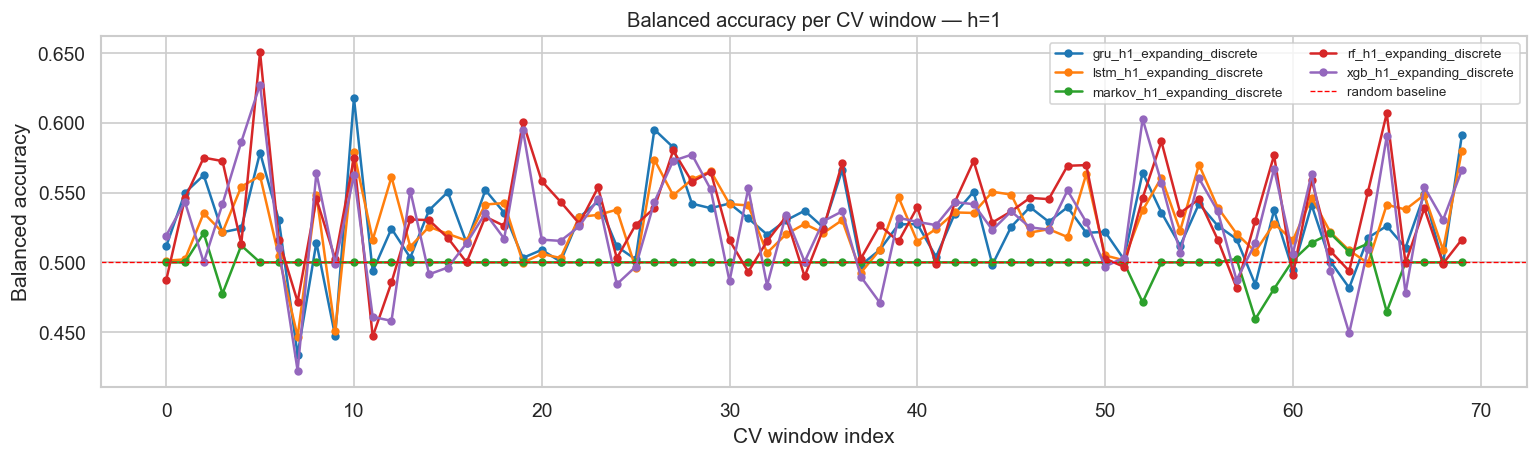

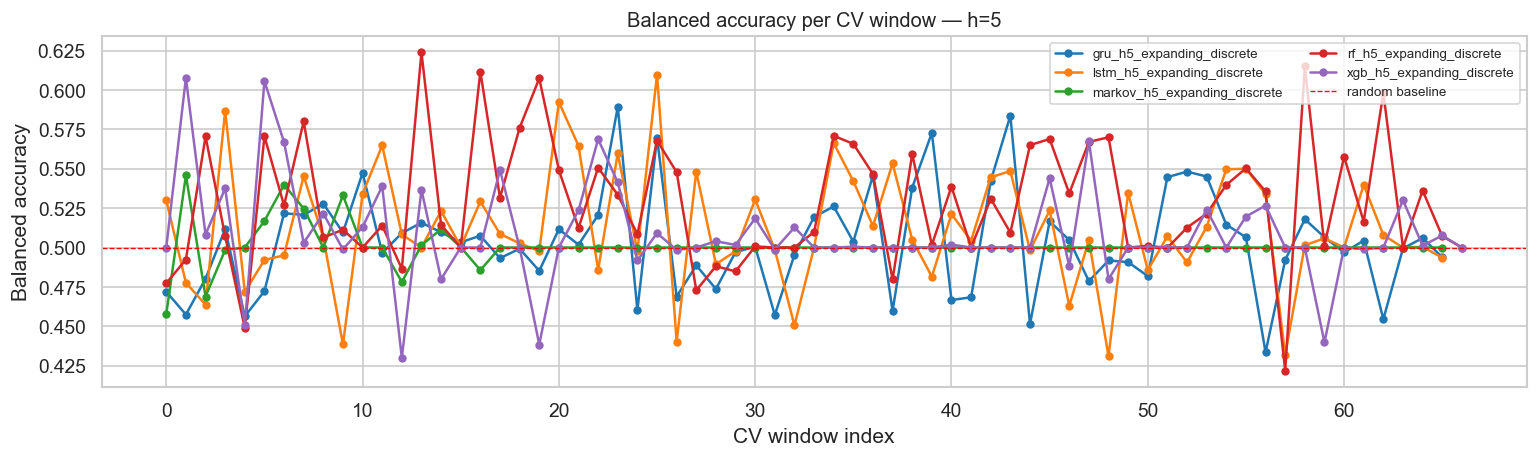

In [6]:
for horizon in sorted(windows_df['horizon'].unique()):
    df_h = windows_df[windows_df['horizon'] == horizon]
    fig, ax = plt.subplots(figsize=(13, 4))

    for name, grp in df_h.groupby('name'):
        ax.plot(grp['window'], grp['balanced_accuracy'], marker='o',
                markersize=4, lw=1.5, label=name)

    ax.axhline(0.5, color='red', lw=0.8, ls='--', label='random baseline')
    ax.set_title(f'Balanced accuracy per CV window — h={horizon}', fontsize=12)
    ax.set_xlabel('CV window index')
    ax.set_ylabel('Balanced accuracy')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

## 5  Head-to-Head Win Rate
For each pair of models (same horizon + mode), count in how many CV windows one beats the other on balanced accuracy.

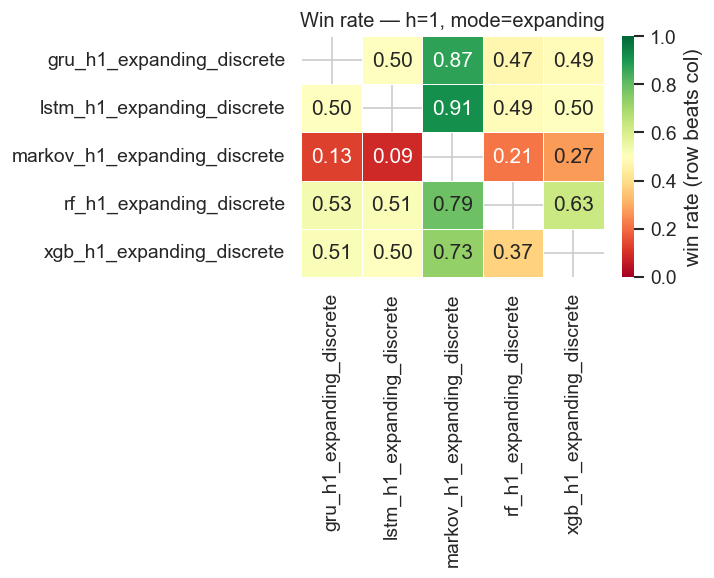

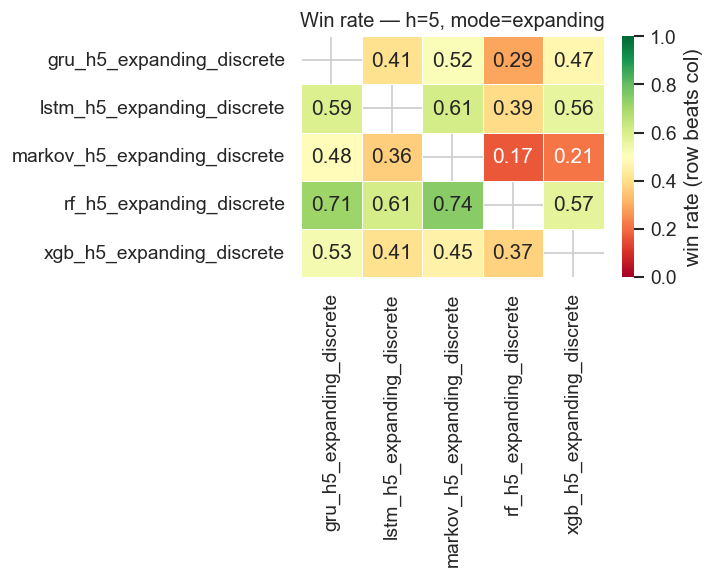

In [7]:
for (horizon, mode), grp in windows_df.groupby(['horizon', 'mode']):
    names = grp['name'].unique()
    if len(names) < 2:
        continue

    pivot = grp.pivot(index='window', columns='name', values='balanced_accuracy')
    n = len(names)
    win_matrix = pd.DataFrame(np.nan, index=names, columns=names)

    for a in names:
        for b in names:
            if a == b:
                continue
            valid = pivot[[a, b]].dropna()
            if len(valid):
                win_matrix.loc[a, b] = (valid[a] > valid[b]).mean()

    fig, ax = plt.subplots(figsize=(max(6, n * 1.2), max(4, n)))
    sns.heatmap(win_matrix.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5, ax=ax,
                cbar_kws={'label': 'win rate (row beats col)'})
    ax.set_title(f'Win rate — h={horizon}, mode={mode}', fontsize=12)
    plt.tight_layout()
    plt.show()

## 6  Feature Importances  (tree models only)

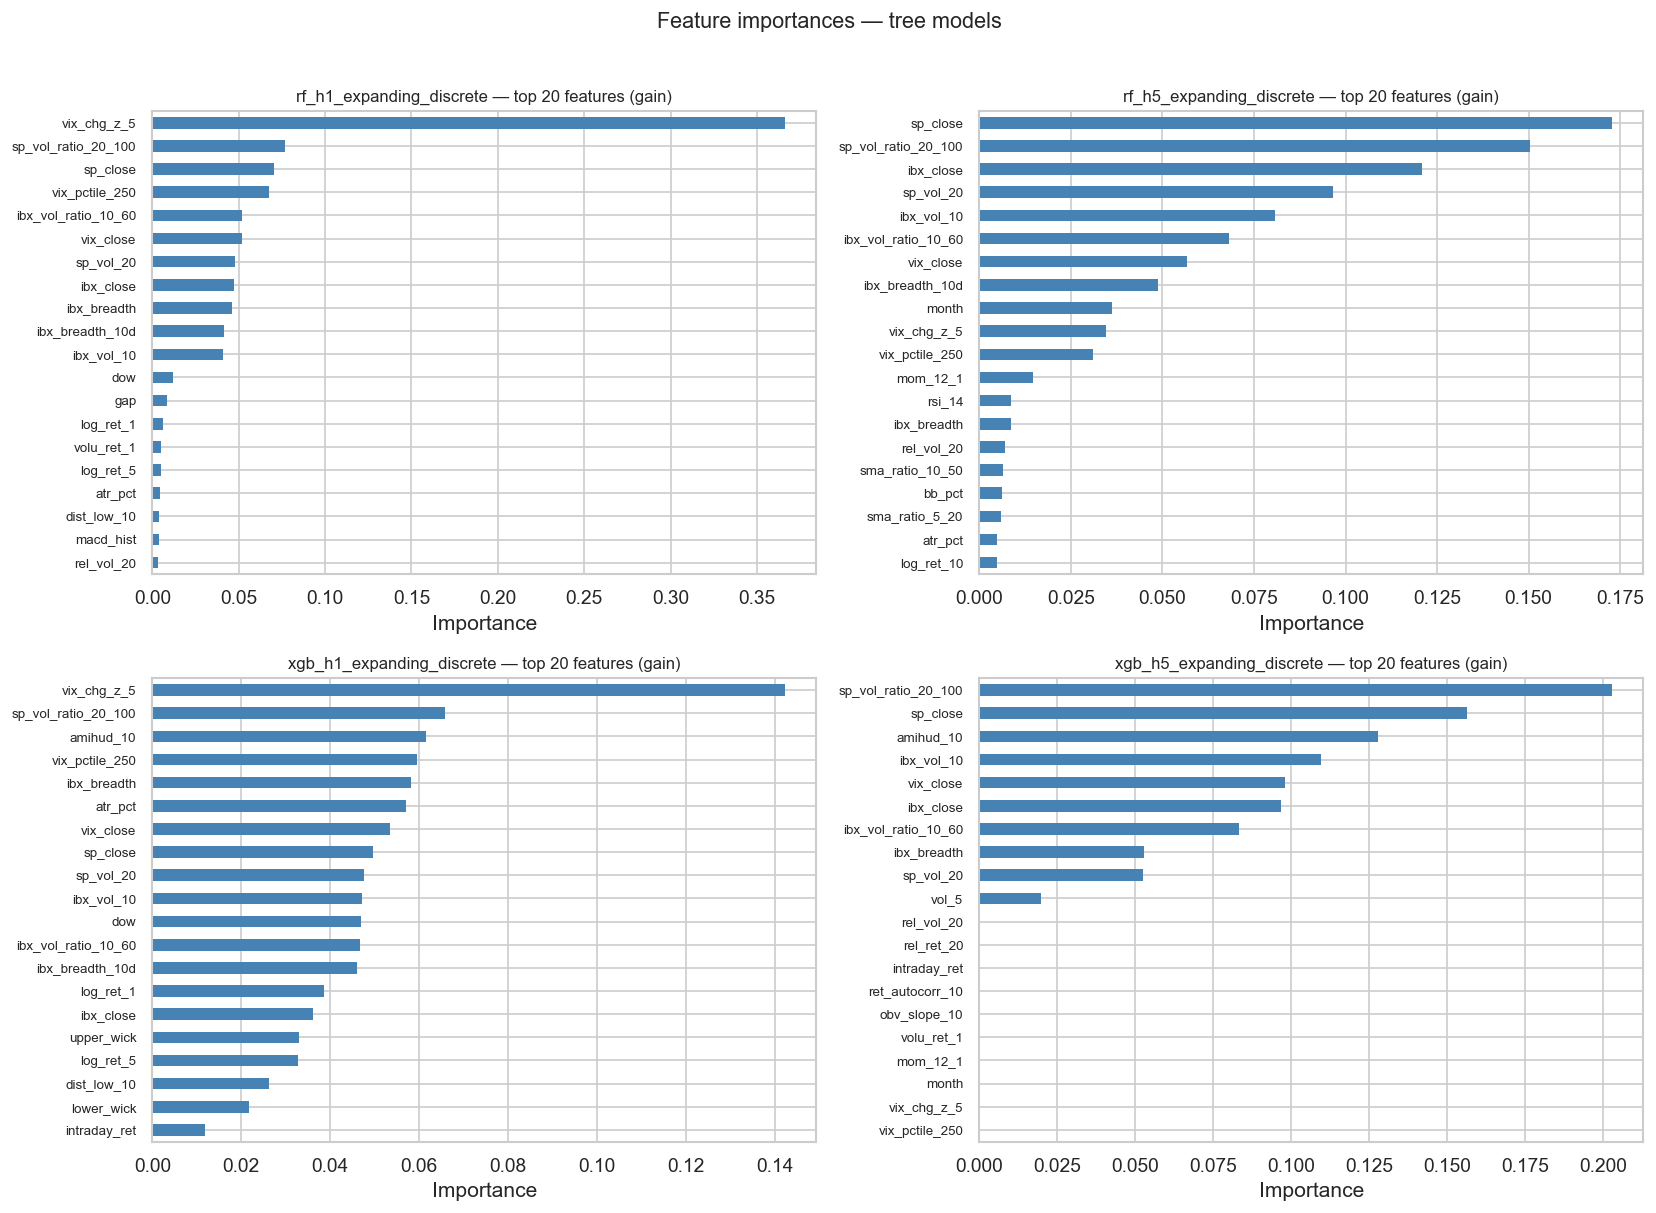

In [8]:
tree_arts = {k: v for k, v in artifacts_discrete.items() if 'feature_importances' in v}

if not tree_arts:
    print('No tree artifacts with feature importances found.')
else:
    ncols = min(2, len(tree_arts))
    nrows = (len(tree_arts) + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows),
                             squeeze=False)

    for ax, (name, a) in zip(axes.flat, tree_arts.items()):
        imps = pd.Series(a['feature_importances']).sort_values(ascending=True).tail(20)
        imps.plot.barh(ax=ax, color='steelblue', edgecolor='none')
        ax.set_title(f'{name} — top 20 features (gain)', fontsize=10)
        ax.set_xlabel('Importance')
        ax.tick_params(axis='y', labelsize=8)

    # hide unused subplots
    for ax in axes.flat[len(tree_arts):]:
        ax.set_visible(False)

    plt.suptitle('Feature importances — tree models', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 7  Model Metadata

In [9]:
meta_rows = []
for stem, a in artifacts_discrete.items():
    row = {
        'artifact':    stem,
        'model':       a['model_key'],
        'h':           a['horizon'],
        'mode':        a['mode'],
        'ft_type':     a['ft_type'],
        'train_start': a['train_start'],
        'train_end':   a['train_end'],
        'window_days': a.get('window_days', '?'),
        'n_features':  len(a.get('features', [])),
        'cv_windows':  len(a['cv_metrics']),
    }
    # tree-specific
    if 'n_rounds_final' in a:
        row['extra'] = f'n_rounds={a["n_rounds_final"]}'
    # neural-specific
    elif 'model_config' in a:
        cfg = a['model_config']
        parts = [f'cell={cfg.get("cell","?")}',
                 f'hidden={cfg.get("hidden_size","?")}',
                 f'seq={a.get("seq_len","?")}',
        ]
        if 'num_filters' in cfg:
            parts.append(f'filters={cfg["num_filters"]}')
        row['extra'] = '  '.join(parts)
    else:
        row['extra'] = ''
    meta_rows.append(row)

meta_df = pd.DataFrame(meta_rows).set_index('artifact')
meta_df.style.set_caption('Artifact metadata').set_table_styles(
    [{'selector': 'caption', 'props': 'font-size:13px; font-weight:bold;'}]
)

,model,h,mode,ft_type,train_start,train_end,window_days,n_features,cv_windows,extra
artifact,,,,,,,,,,
gru_h1_expanding_discrete,gru,1,expanding,macro,2006-03-13,2026-04-23,5136,44,70,cell=gru hidden=64 seq=20
gru_h5_expanding_discrete,gru,5,expanding,macro,2006-12-28,2026-04-17,4929,46,66,cell=gru hidden=64 seq=20
lstm_h1_expanding_discrete,lstm,1,expanding,macro,2006-03-13,2026-04-23,5136,44,70,cell=lstm hidden=64 seq=20
lstm_h5_expanding_discrete,lstm,5,expanding,macro,2006-12-28,2026-04-17,4929,46,66,cell=lstm hidden=64 seq=20
markov_h1_expanding_discrete,markov,1,expanding,macro,2006-03-13,2026-04-23,5136,1,70,
markov_h5_expanding_discrete,markov,5,expanding,macro,2006-12-28,2026-04-17,4929,1,66,
rf_h1_expanding_discrete,rf,1,expanding,macro,2006-03-13,2026-04-23,5136,43,70,
rf_h5_expanding_discrete,rf,5,expanding,macro,2006-12-28,2026-04-23,4933,44,67,
xgb_h1_expanding_discrete,xgb,1,expanding,macro,2006-03-13,2026-04-22,5135,43,70,n_rounds=36


## 8  Metric Correlation across Windows

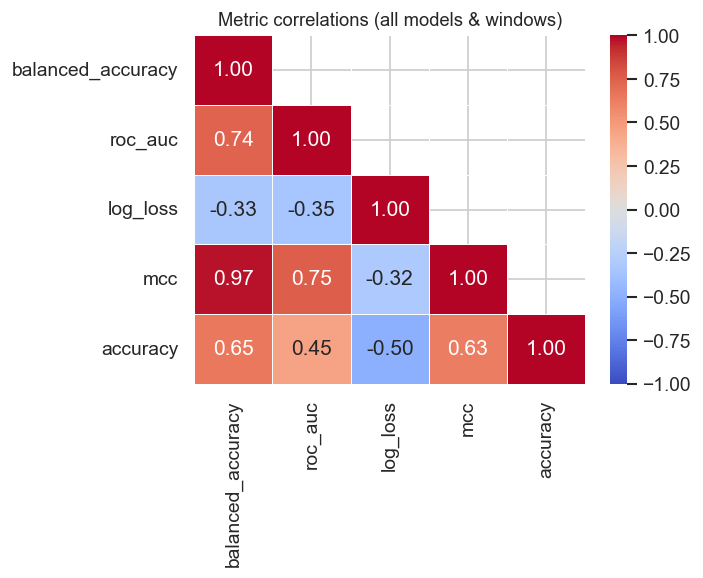

In [10]:
if len(windows_df) > 0:
    corr = windows_df[METRICS].corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, mask=mask, linewidths=0.5, ax=ax)
    ax.set_title('Metric correlations (all models & windows)', fontsize=11)
    plt.tight_layout()
    plt.show()

## 9  Sliding vs Expanding — direct comparison
Only shown when the same model was trained under both modes.

In [11]:
# Find models that appear in both sliding and expanding
s_df = summary[summary['mode'] == 'sliding']
e_df = summary[summary['mode'] == 'expanding']
common = set(s_df['model']) & set(e_df['model'])

if not common:
    print('No model has been trained under both modes yet.')
else:
    compare_rows = []
    for model in sorted(common):
        for m in ['balanced_accuracy', 'roc_auc', 'mcc']:
            s_val = s_df[s_df['model'] == model][f'{m}_mean'].values[0]
            e_val = e_df[e_df['model'] == model][f'{m}_mean'].values[0]
            compare_rows.append({'model': model, 'metric': m,
                                  'sliding': s_val, 'expanding': e_val,
                                  'delta (exp-sli)': e_val - s_val})

    comp_df = pd.DataFrame(compare_rows)
    comp_df.style \
        .background_gradient(subset=['delta (exp-sli)'], cmap='RdYlGn', vmin=-0.02, vmax=0.02) \
        .format({'sliding': '{:.4f}', 'expanding': '{:.4f}', 'delta (exp-sli)': '{:+.4f}'}) \
        .set_caption('Sliding vs Expanding — mean CV metrics')

No model has been trained under both modes yet.


## 10  Is the Extra Complexity Worth It?
Model complexity is defined as trainable parameter count (neural) or effective node count (tree ensembles). We ask: does each step up in complexity deliver a proportional gain in balanced accuracy?

In [12]:
def model_complexity(a: dict) -> int:
    """Rough complexity score comparable across model families.

    Trees  : n_trees x nodes_per_tree  (effective leaf count)
    Neural : trainable parameter count
    """
    key = a["model_key"]
    p   = a.get("params", {})
    if key == "rf":
        return p.get("n_estimators", 500) * (2 ** p.get("max_depth", 5) - 1)
    if key == "xgb":
        n_rounds = a.get("n_rounds_final", p.get("n_estimators", 150))
        return n_rounds * (2 ** p.get("max_depth", 3) - 1)
    # neural
    cfg  = a["model_config"]
    h, inp = cfg["hidden_size"], cfg["input_size"]
    mult = 4 if cfg.get("cell", "gru") == "lstm" else 3
    if "num_filters" in cfg:
        f, k = cfg["num_filters"], cfg["kernel_size"]
        conv = inp * f * k + f + 2 * f
        rnn  = mult * (f * h + h * h + h)
    else:
        conv = 0
        rnn  = mult * (inp * h + h * h + h)
    return conv + rnn + h + 1

cplx_rows = []
for stem, a in artifacts_discrete.items():
    cplx_rows.append({
        "name":       stem,
        "model":      a["model_key"],
        "horizon":    a["horizon"],
        "complexity": model_complexity(a),
        "ba_mean":    a["cv_summary"]["balanced_accuracy"]["mean"],
        "ba_std":     a["cv_summary"]["balanced_accuracy"]["std"],
        "auc_mean":   a["cv_summary"]["roc_auc"]["mean"],
    })
cplx_df = pd.DataFrame(cplx_rows).sort_values("complexity").reset_index(drop=True)
print(cplx_df[["name", "complexity", "ba_mean", "ba_std"]].to_string(index=False))


KeyError: 'model_config'

In [13]:
for horizon in sorted(cplx_df["horizon"].unique()):
    df_h = cplx_df[cplx_df["horizon"] == horizon].copy()
    if df_h.empty:
        continue

    baseline_ba   = df_h.sort_values("complexity").iloc[0]["ba_mean"]
    baseline_name = df_h.sort_values("complexity").iloc[0]["name"]
    df_h["delta_ba"] = df_h["ba_mean"] - baseline_ba

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- left: scatter complexity vs accuracy ---
    ax = axes[0]
    colors = sns.color_palette("tab10", len(df_h))
    for i, (_, row) in enumerate(df_h.iterrows()):
        ax.scatter(row["complexity"], row["ba_mean"], s=130,
                   color=colors[i % 10], zorder=3)
        ax.errorbar(row["complexity"], row["ba_mean"],
                    yerr=row["ba_std"], fmt="none",
                    color=colors[i % 10], lw=1.2, capsize=4)
        ax.annotate(row["name"], (row["complexity"], row["ba_mean"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=8)
    ax.axhline(0.5, color="red", ls="--", lw=0.8, label="random")
    ax.set_xscale("log")
    ax.set_xlabel("Model complexity  (log scale)", fontsize=10)
    ax.set_ylabel("Balanced accuracy (CV mean)", fontsize=10)
    ax.set_title(f"Complexity vs Performance  —  h={horizon}", fontsize=11)
    ax.legend(fontsize=8)

    # --- right: marginal gain bars ---
    ax2 = axes[1]
    df_s = df_h.sort_values("complexity")
    bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in df_s["delta_ba"]]
    bars = ax2.barh(df_s["name"], df_s["delta_ba"] * 100,
                    color=bar_colors, edgecolor="white", height=0.55)
    ax2.axvline(0, color="black", lw=0.8)
    ax2.set_xlabel(f"Balanced accuracy gain vs {baseline_name} (pp)", fontsize=10)
    ax2.set_title(f"Marginal gain over simplest model  —  h={horizon}", fontsize=11)
    for bar, val in zip(bars, df_s["delta_ba"] * 100):
        ax2.text(val + (0.05 if val >= 0 else -0.05),
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:+.2f}pp", va="center",
                 ha="left" if val >= 0 else "right", fontsize=8)
    plt.tight_layout()
    plt.show()


NameError: name 'cplx_df' is not defined

In [14]:
# Efficiency table: balanced-accuracy gain per unit of log-complexity increase
eff_rows = []
for horizon in sorted(cplx_df["horizon"].unique()):
    df_h = cplx_df[cplx_df["horizon"] == horizon].sort_values("complexity")
    base = df_h.iloc[0]
    for _, row in df_h.iterrows():
        ratio    = max(row["complexity"], 1) / max(base["complexity"], 1)
        log_r    = np.log10(ratio)
        delta_pp = (row["ba_mean"] - base["ba_mean"]) * 100
        eff      = delta_pp / log_r if log_r > 0.01 else float("nan")
        verdict  = (
            "baseline" if row["name"] == base["name"]
            else "YES"      if delta_pp >= 0.5
            else "MARGINAL" if delta_pp >= 0.1
            else "NO"
        )
        eff_rows.append({
            "artifact":        row["name"],
            "h":               horizon,
            "complexity":      f"{row['complexity']:,}",
            "ba_mean":         f"{row['ba_mean']:.4f}",
            "delta_ba (pp)":   f"{delta_pp:+.2f}",
            "pp / log10(C/C0)": f"{eff:.2f}" if not np.isnan(eff) else "—",
            "worth it?":       verdict,
        })

eff_df = pd.DataFrame(eff_rows)

def _verdict_color(val):
    return {
        "YES":      "background-color:#c8f7c5",
        "MARGINAL": "background-color:#fef9c3",
        "NO":       "background-color:#ffd5d5",
    }.get(val, "")

eff_df.style \
    .applymap(_verdict_color, subset=["worth it?"]) \
    .set_caption("Complexity efficiency — is the extra complexity justified?") \
    .set_table_styles([{"selector": "caption",
                        "props": "font-size:13px; font-weight:bold;"}])


NameError: name 'cplx_df' is not defined

---
# Section 2 — Continuous Artifacts (Regression)
Mirrors Section 1 but with regression metrics: **IC** (primary, Spearman), MAE, RMSE, R², directional accuracy.


## 2.0  Load continuous artifacts into DataFrames

In [15]:
CONT_METRICS = ['ic', 'mae', 'rmse', 'r2', 'directional_accuracy']

if not artifacts_cont:
    print("No continuous artifacts loaded — Section 2 skipped.")
    summary_c = pd.DataFrame()
    windows_c = pd.DataFrame()
else:
    rows_c = []
    for stem, a in artifacts_cont.items():
        row = {
            'name':    stem,
            'model':   a['model_key'],
            'horizon': a['horizon'],
            'mode':    a['mode'],
            'ft_type': a['ft_type'],
            'windows': len(a['cv_metrics']),
            'train_start': a['train_start'],
            'train_end':   a['train_end'],
        }
        for m in CONT_METRICS:
            s = a['cv_summary'].get(m, {})
            row[f'{m}_mean'] = s.get('mean', np.nan)
            row[f'{m}_std']  = s.get('std',  np.nan)
        rows_c.append(row)

    summary_c = pd.DataFrame(rows_c).set_index('name')

    window_rows_c = []
    for stem, a in artifacts_cont.items():
        for wi, m in enumerate(a['cv_metrics']):
            window_rows_c.append({
                'name':    stem,
                'model':   a['model_key'],
                'horizon': a['horizon'],
                'mode':    a['mode'],
                'window':  wi,
                **{k: v for k, v in m.items() if k in CONT_METRICS},
            })
    windows_c = pd.DataFrame(window_rows_c)

    print('Continuous summary shape:', summary_c.shape)
    print('Continuous windows df shape:', windows_c.shape)


No continuous artifacts loaded — Section 2 skipped.


## 2.1  CV Metrics Summary Table

In [16]:
if summary_c.empty:
    print("No continuous artifacts.")
else:
    def fmt_c(mean, std):
        return f"{mean:.4f} ± {std:.4f}"

    disp_cols_c = ['model', 'horizon', 'mode', 'ft_type', 'windows']
    sc = summary_c.copy()
    for m in CONT_METRICS:
        sc[m] = sc.apply(lambda r: fmt_c(r[f'{m}_mean'], r[f'{m}_std']), axis=1)

    sc.sort_values(['horizon', 'ic_mean'], ascending=[True, False])[disp_cols_c + CONT_METRICS].style \
        .set_caption('Continuous CV metrics  (mean ± std across windows)') \
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:13px; font-weight:bold;'}])

No continuous artifacts.


## 2.2  Per-Window Distributions  (boxplots)

In [17]:
if windows_c.empty:
    print("No continuous artifacts.")
else:
    primary_c = ['ic', 'directional_accuracy', 'mae', 'rmse']
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, metric in zip(axes.flat, primary_c):
        order = (
            windows_c.groupby('name')[metric].median()
              .sort_values(ascending=(metric in ('mae', 'rmse'))).index.tolist()
        )
        palette = {n: sns.color_palette('tab10')[i % 10] for i, n in enumerate(order)}
        sns.boxplot(data=windows_c, x=metric, y='name', order=order,
                    palette=palette, width=0.55, linewidth=0.9,
                    flierprops=dict(marker='x', markersize=4), ax=ax)
        ax.set_title(metric.replace('_', ' ').title(), fontsize=11)
        ax.set_xlabel(''); ax.set_ylabel('')
        if metric == 'ic':
            ax.axvline(0, color='red', lw=0.8, ls='--', label='IC=0')
            ax.legend(fontsize=8)
    plt.suptitle('Continuous: per-window CV distribution by model', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()


No continuous artifacts.


## 2.3  IC over CV Windows  (temporal trend)

In [18]:
if windows_c.empty:
    print("No continuous artifacts.")
else:
    for horizon in sorted(windows_c['horizon'].unique()):
        df_h = windows_c[windows_c['horizon'] == horizon]
        fig, ax = plt.subplots(figsize=(13, 4))
        for name, grp in df_h.groupby('name'):
            ax.plot(grp['window'], grp['ic'], marker='o',
                    markersize=4, lw=1.5, label=name)
        ax.axhline(0, color='red', lw=0.8, ls='--', label='IC=0')
        ax.set_title(f'IC per CV window — h={horizon}', fontsize=12)
        ax.set_xlabel('CV window index')
        ax.set_ylabel('Spearman IC')
        ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
        ax.legend(loc='upper right', fontsize=8, ncol=2)
        plt.tight_layout(); plt.show()


No continuous artifacts.


## 2.4  Head-to-Head Win Rate
For each pair of continuous models (same horizon + mode), fraction of CV windows where one beats the other on IC.


In [19]:
if windows_c.empty:
    print("No continuous artifacts.")
else:
    for (horizon, mode), grp in windows_c.groupby(['horizon', 'mode']):
        names = grp['name'].unique()
        if len(names) < 2:
            continue
        pivot = grp.pivot(index='window', columns='name', values='ic')
        n = len(names)
        win_matrix = pd.DataFrame(np.nan, index=names, columns=names)
        for a in names:
            for b in names:
                if a == b: continue
                valid = pivot[[a, b]].dropna()
                if len(valid):
                    win_matrix.loc[a, b] = (valid[a] > valid[b]).mean()
        fig, ax = plt.subplots(figsize=(max(6, n * 1.2), max(4, n)))
        sns.heatmap(win_matrix.astype(float), annot=True, fmt='.2f',
                    cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5, ax=ax,
                    cbar_kws={'label': 'win rate (row beats col on IC)'})
        ax.set_title(f'IC Win rate — h={horizon}, mode={mode}', fontsize=12)
        plt.tight_layout(); plt.show()


No continuous artifacts.


## 2.5  Model Metadata

In [20]:
if not artifacts_cont:
    print("No continuous artifacts.")
else:
    meta_rows_c = []
    for stem, a in artifacts_cont.items():
        row = {
            'artifact':    stem,
            'model':       a['model_key'],
            'h':           a['horizon'],
            'mode':        a['mode'],
            'ft_type':     a['ft_type'],
            'train_start': a['train_start'],
            'train_end':   a['train_end'],
            'window_days': a.get('window_days', '?'),
            'n_features':  len(a.get('features', [])),
            'cv_windows':  len(a['cv_metrics']),
        }
        if 'n_rounds_final' in a:
            row['extra'] = f'n_rounds={a["n_rounds_final"]}'
        elif 'model_config' in a:
            cfg = a['model_config']
            parts = [f'cell={cfg.get("cell","?")}',
                     f'hidden={cfg.get("hidden_size","?")}',
                     f'seq={a.get("seq_len","?")}',]
            if 'num_filters' in cfg:
                parts.append(f'filters={cfg["num_filters"]}')
            row['extra'] = '  '.join(parts)
        else:
            row['extra'] = ''
        meta_rows_c.append(row)

    pd.DataFrame(meta_rows_c).set_index('artifact').style \
        .set_caption('Continuous artifact metadata') \
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:13px; font-weight:bold;'}])


No continuous artifacts.


## 2.6  Sliding vs Expanding — direct comparison
Only shown when the same continuous model was trained under both modes.


In [21]:
if summary_c.empty:
    print("No continuous artifacts.")
else:
    s_c = summary_c[summary_c['mode'] == 'sliding']
    e_c = summary_c[summary_c['mode'] == 'expanding']
    common_c = set(s_c['model']) & set(e_c['model'])
    if not common_c:
        print("No continuous model has been trained under both modes yet.")
    else:
        cmp_rows = []
        for model in sorted(common_c):
            for m in ['ic', 'directional_accuracy', 'mae']:
                s_val = s_c[s_c['model'] == model][f'{m}_mean'].values[0]
                e_val = e_c[e_c['model'] == model][f'{m}_mean'].values[0]
                cmp_rows.append({'model': model, 'metric': m,
                                  'sliding': s_val, 'expanding': e_val,
                                  'delta (exp-sli)': e_val - s_val})
        pd.DataFrame(cmp_rows).style \
            .background_gradient(subset=['delta (exp-sli)'], cmap='RdYlGn', vmin=-0.02, vmax=0.02) \
            .format({'sliding': '{:.4f}', 'expanding': '{:.4f}', 'delta (exp-sli)': '{:+.4f}'}) \
            .set_caption('Sliding vs Expanding — continuous CV metrics')


No continuous artifacts.


## 2.7  Is the Extra Complexity Worth It?  (Continuous)
Reuses `model_complexity()` from Section 1. Primary metric: IC instead of balanced accuracy.


In [22]:
if not artifacts_cont:
    print("No continuous artifacts.")
else:
    cplx_rows_c = []
    for stem, a in artifacts_cont.items():
        cplx_rows_c.append({
            "name":       stem,
            "model":      a["model_key"],
            "horizon":    a["horizon"],
            "complexity": model_complexity(a),
            "ic_mean":    a["cv_summary"]["ic"]["mean"],
            "ic_std":     a["cv_summary"]["ic"]["std"],
            "da_mean":    a["cv_summary"]["directional_accuracy"]["mean"],
        })
    cplx_c = pd.DataFrame(cplx_rows_c).sort_values("complexity").reset_index(drop=True)
    print(cplx_c[["name", "complexity", "ic_mean", "ic_std"]].to_string(index=False))

    for horizon in sorted(cplx_c["horizon"].unique()):
        df_h = cplx_c[cplx_c["horizon"] == horizon].copy()
        if df_h.empty: continue
        baseline_ic   = df_h.sort_values("complexity").iloc[0]["ic_mean"]
        baseline_name = df_h.sort_values("complexity").iloc[0]["name"]
        df_h["delta_ic"] = df_h["ic_mean"] - baseline_ic

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        colors = sns.color_palette("tab10", len(df_h))
        ax = axes[0]
        for i, (_, row) in enumerate(df_h.iterrows()):
            ax.scatter(row["complexity"], row["ic_mean"], s=130,
                       color=colors[i % 10], zorder=3)
            ax.errorbar(row["complexity"], row["ic_mean"],
                        yerr=row["ic_std"], fmt="none",
                        color=colors[i % 10], lw=1.2, capsize=4)
            ax.annotate(row["name"], (row["complexity"], row["ic_mean"]),
                        xytext=(6, 4), textcoords="offset points", fontsize=8)
        ax.axhline(0, color="red", ls="--", lw=0.8, label="IC=0")
        ax.set_xscale("log")
        ax.set_xlabel("Model complexity  (log scale)", fontsize=10)
        ax.set_ylabel("IC (CV mean)", fontsize=10)
        ax.set_title(f"Complexity vs IC  —  h={horizon}", fontsize=11)
        ax.legend(fontsize=8)

        ax2 = axes[1]
        bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in df_h["delta_ic"]]
        bars = ax2.barh(df_h["name"], df_h["delta_ic"],
                        color=bar_colors, edgecolor="white", height=0.55)
        ax2.axvline(0, color="black", lw=0.8)
        ax2.set_xlabel(f"IC gain vs {baseline_name}", fontsize=10)
        ax2.set_title(f"Marginal IC gain  —  h={horizon}", fontsize=11)
        for bar, val in zip(bars, df_h["delta_ic"]):
            ax2.text(val + (0.001 if val >= 0 else -0.001),
                     bar.get_y() + bar.get_height() / 2,
                     f"{val:+.4f}", va="center",
                     ha="left" if val >= 0 else "right", fontsize=8)
        plt.tight_layout(); plt.show()


No continuous artifacts.
